In [4]:
# Run this once to install
import subprocess
subprocess.run(["pip", "install", "yfinance", "pandas", "numpy", "matplotlib"])

CompletedProcess(args=['pip', 'install', 'yfinance', 'pandas', 'numpy', 'matplotlib'], returncode=0)

In [5]:
#Import libraries 
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All imports successful!")

All imports successful!


In [6]:
# Download S&P 500 (the market index)
sp500 = yf.download("^GSPC", start="1993-01-01", end="2024-12-31")

# Download VIX (the fear index)
vix = yf.download("^VIX", start="1993-01-01", end="2024-12-31")

# Look at the first 5 rows
print("S&P 500 data:")
print(sp500.head())

print("\nVIX data:")
print(vix.head())

print(f"\nTotal trading days downloaded: {len(sp500)}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

S&P 500 data:
Price            Close        High         Low        Open     Volume
Ticker           ^GSPC       ^GSPC       ^GSPC       ^GSPC      ^GSPC
Date                                                                 
1993-01-04  435.380005  437.320007  434.480011  435.700012  201210000
1993-01-05  434.339996  435.399994  433.549988  435.380005  240350000
1993-01-06  434.519989  435.170013  432.519989  434.339996  295240000
1993-01-07  430.730011  435.459991  429.760010  434.519989  304850000
1993-01-08  429.049988  430.730011  426.880005  430.730011  263470000

VIX data:
Price       Close   High    Low   Open Volume
Ticker       ^VIX   ^VIX   ^VIX   ^VIX   ^VIX
Date                                         
1993-01-04  13.36  13.92  12.91  12.96      0
1993-01-05  13.35  14.08  12.92  12.99      0
1993-01-06  13.37  14.17  11.86  12.88      0
1993-01-07  14.72  15.06  12.65  12.90      0
1993-01-08  13.77  14.39  13.61  13.75      0

Total trading days downloaded: 8056


In [7]:
# Log return = log(today's price / yesterday's price)
sp500['log_return'] = np.log(sp500['Close'] / sp500['Close'].shift(1))
vix['log_return']   = np.log(vix['Close']   / vix['Close'].shift(1))

# Drop the first row (it becomes NaN because there's no "yesterday")
sp500 = sp500.dropna()
vix   = vix.dropna()

# Quick check — print mean and std of returns
print(f"Mean daily return: {sp500['log_return'].mean():.7f}")
print(f"Std of returns:    {sp500['log_return'].std():.6f}")
print(f"\nFirst few log returns:")
print(sp500['log_return'].head(10))

Mean daily return: 0.0003237
Std of returns:    0.011609

First few log returns:
Date
1993-01-05   -0.002392
1993-01-06    0.000414
1993-01-07   -0.008760
1993-01-08   -0.003908
1993-01-11    0.004419
1993-01-12    0.000209
1993-01-13    0.004606
1993-01-14    0.006698
1993-01-15    0.002772
1993-01-18   -0.000709
Name: log_return, dtype: float64


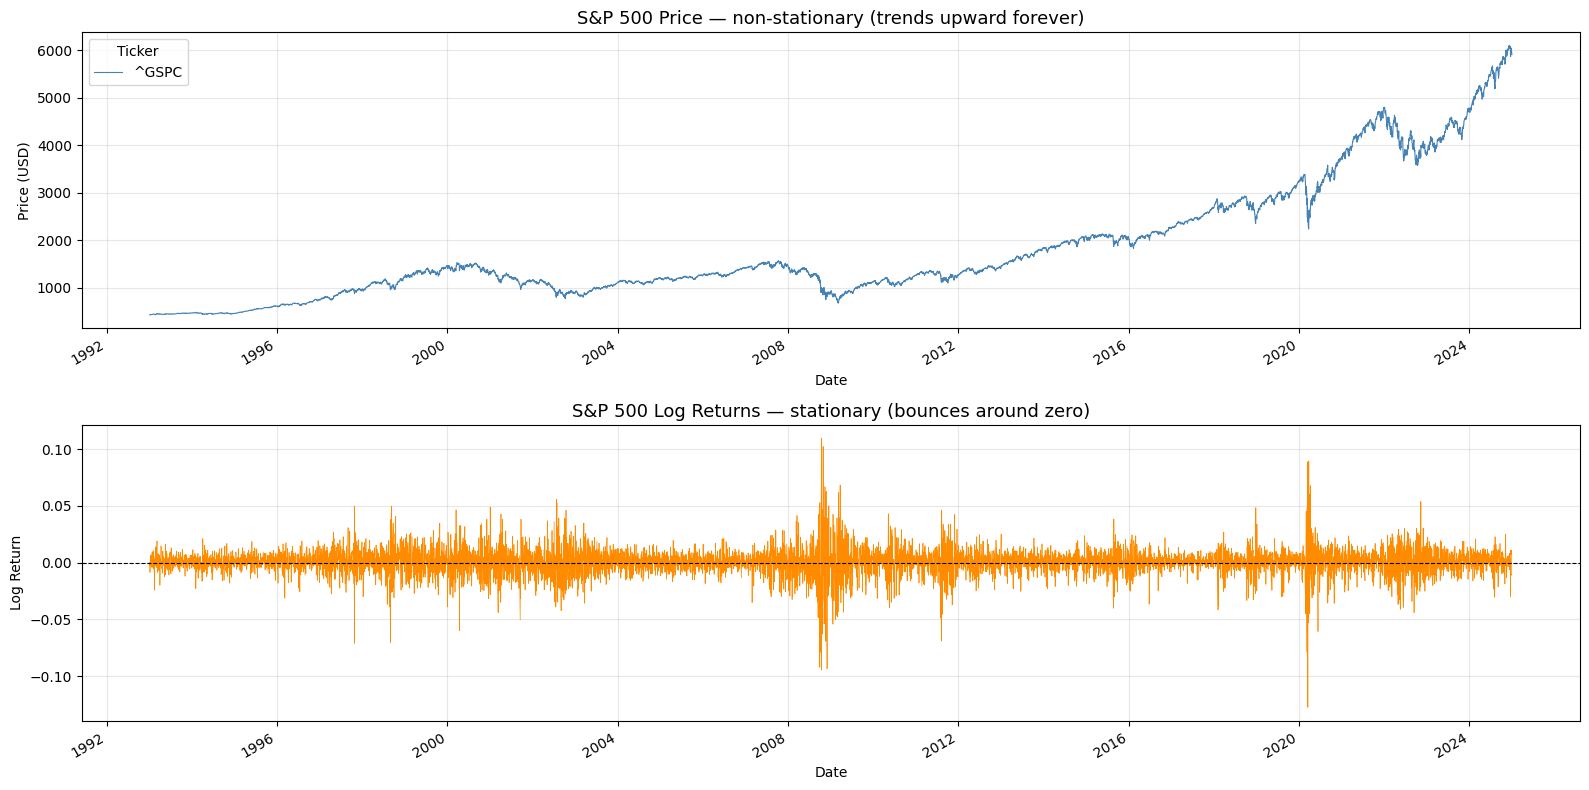

Plot saved as prices_vs_returns.png


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))

# Top plot — raw price (non-stationary, trends upward)
sp500['Close'].plot(ax=ax1, color='steelblue', linewidth=0.8)
ax1.set_title('S&P 500 Price — non-stationary (trends upward forever)', fontsize=13)
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

# Bottom plot — log returns (stationary, bounces around zero)
sp500['log_return'].plot(ax=ax2, color='darkorange', linewidth=0.5)
ax2.set_title('S&P 500 Log Returns — stationary (bounces around zero)', fontsize=13)
ax2.set_ylabel('Log Return')
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prices_vs_returns.png', dpi=150)
plt.show()

print("Plot saved as prices_vs_returns.png")

In [9]:
# Rolling volatility = standard deviation of returns over a window
sp500['vol_20d']  = sp500['log_return'].rolling(window=20).std()   # 1 month
sp500['vol_60d']  = sp500['log_return'].rolling(window=60).std()   # 3 months
sp500['vol_120d'] = sp500['log_return'].rolling(window=120).std()  # 6 months

print("Volatility columns added:")
print(sp500[['log_return', 'vol_20d', 'vol_60d', 'vol_120d']].tail(10))

Volatility columns added:
Price      log_return   vol_20d   vol_60d  vol_120d
Ticker                                             
Date                                               
2024-12-16   0.003792  0.004038  0.006526  0.008638
2024-12-17  -0.003871  0.004186  0.006553  0.008649
2024-12-18  -0.029937  0.008095  0.007665  0.009083
2024-12-19  -0.000865  0.008095  0.007661  0.009082
2024-12-20   0.010810  0.008388  0.007765  0.009116
2024-12-23   0.007261  0.008516  0.007809  0.009127
2024-12-24   0.010982  0.008843  0.007910  0.009166
2024-12-26  -0.000406  0.008756  0.007798  0.009166
2024-12-27  -0.011117  0.009076  0.007952  0.009229
2024-12-30  -0.010760  0.009258  0.008084  0.009244


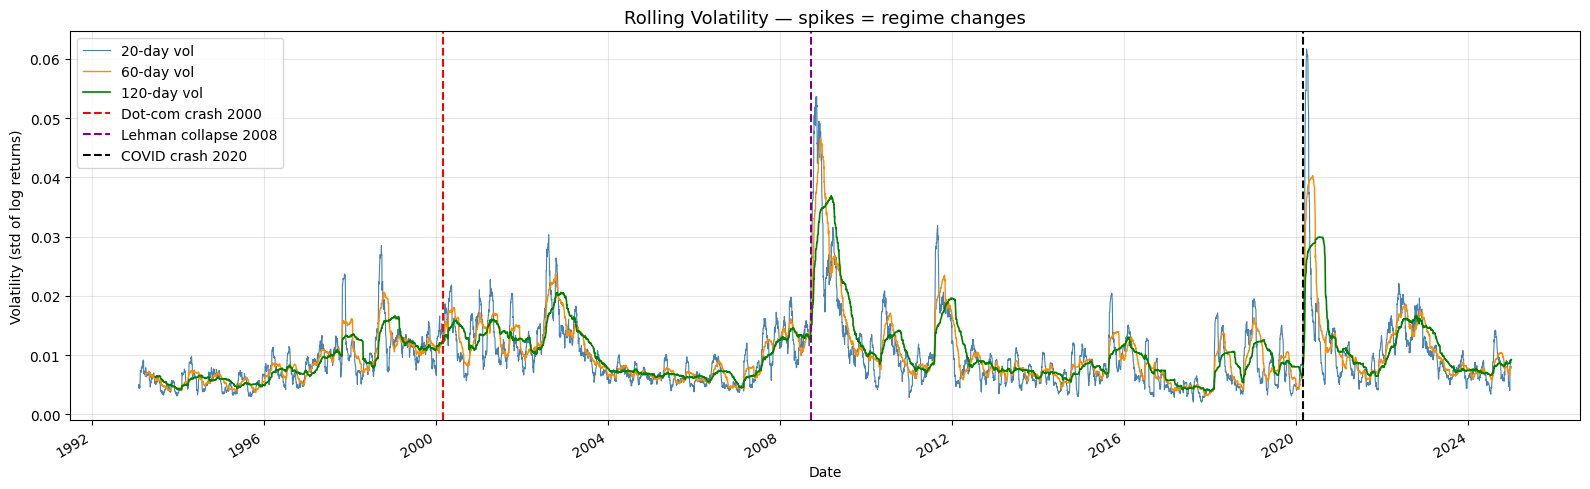

Plot saved as rolling_volatility.png


In [10]:
fig, ax = plt.subplots(figsize=(16, 5))

# Plot all three rolling volatilities
sp500['vol_20d'].plot(ax=ax,  color='steelblue',  linewidth=0.8, label='20-day vol')
sp500['vol_60d'].plot(ax=ax,  color='darkorange',  linewidth=1.0, label='60-day vol')
sp500['vol_120d'].plot(ax=ax, color='green',       linewidth=1.2, label='120-day vol')

# Mark the major crises — these are your regime change points
ax.axvline(x='2000-03-01', color='red',    linestyle='--', linewidth=1.5, label='Dot-com crash 2000')
ax.axvline(x='2008-09-15', color='purple', linestyle='--', linewidth=1.5, label='Lehman collapse 2008')
ax.axvline(x='2020-03-01', color='black',  linestyle='--', linewidth=1.5, label='COVID crash 2020')

ax.set_title('Rolling Volatility — spikes = regime changes', fontsize=13)
ax.set_ylabel('Volatility (std of log returns)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rolling_volatility.png', dpi=150)
plt.show()

print("Plot saved as rolling_volatility.png")

In [11]:
# Clean data — drop any remaining NaN rows
data = sp500[['Close', 'log_return', 'vol_20d', 'vol_60d', 'vol_120d']].dropna()

# Split 80% train, 20% test — BY TIME, never randomly
split_index = int(len(data) * 0.80)

train = data.iloc[:split_index]
test  = data.iloc[split_index:]

print(f"Total days:  {len(data)}")
print(f"Train days:  {len(train)}  ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Test days:   {len(test)}   ({test.index[0].date()} to {test.index[-1].date()})")

Total days:  7936
Train days:  6348  (1993-06-24 to 2018-09-06)
Test days:   1588   (2018-09-07 to 2024-12-30)


In [12]:
# Save everything so you don't re-download tomorrow
data.to_csv('sp500_clean.csv')
vix[['Close', 'log_return']].to_csv('vix_clean.csv')

print("Saved: sp500_clean.csv")
print("Saved: vix_clean.csv")
print("\nYour data summary:")
print(data.describe().round(6))

Saved: sp500_clean.csv
Saved: vix_clean.csv

Your data summary:
Price         Close   log_return      vol_20d      vol_60d     vol_120d
Ticker        ^GSPC                                                    
count   7936.000000  7936.000000  7936.000000  7936.000000  7936.000000
mean    1838.384456     0.000326     0.009902     0.010183     0.010385
std     1236.145173     0.011670     0.006306     0.005751     0.005331
min      438.920013    -0.127652     0.002069     0.003141     0.003927
25%     1079.197510    -0.004497     0.006019     0.006692     0.006984
50%     1342.284973     0.000635     0.008424     0.008501     0.008652
75%     2300.007568     0.005794     0.012001     0.012232     0.012656
max     6090.270020     0.109572     0.061669     0.046635     0.036913
